# Image Segmentation with U-Net (PyTorch)

This notebook is a PyTorch port of the TensorFlow/Keras U-Net implementation, based on:
* **Algorithm**: Ronneberger et al., [U-Net](https://arxiv.org/abs/1505.04597) Convolutional Networks for Biomedical Image Segmentation
* **Dataset**: [Oxford-IIIT Pet dataset](https://www.kaggle.com/tanlikesmath/the-oxfordiiit-pet-dataset) (published on Kaggle)

The model, data loading, training loop, and visualization helpers live in separate modules
alongside this notebook (`unet_model.py`, `unet_dataset.py`, `unet_train.py`, `unet_viz.py`),
matching the `helper_*.py` convention already used elsewhere in `L09/`. This notebook just
orchestrates them.

<a name='0'></a>
# 0 - Google Colab Setup (optional)

Skip this cell if you're running locally. On Colab, it mounts Google Drive and `cd`s into the
folder where you've placed `unet_model.py`, `unet_dataset.py`, `unet_train.py`, `unet_viz.py`,
and the two dataset archives (`images.tar.gz`, `annotations.tar.gz`) — update `COLAB_DIR` below
to match. Everything after this cell then behaves exactly as it does locally, since the rest of
the notebook just assumes those files are in the current working directory.

In [3]:
import os

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    # Point this at the Drive folder containing unet_model.py, unet_dataset.py, unet_train.py,
    # unet_viz.py, images.tar.gz, and annotations.tar.gz
    COLAB_DIR = COLAB_DIR = '/content/drive/MyDrive/mscs635'
    os.chdir(COLAB_DIR)

    # Extract the dataset archives once; skip if already extracted from a previous run
    if not os.path.isdir('data/images') or not os.path.isdir('data/masks'):
        import tarfile

        os.makedirs('data/images', exist_ok=True)
        os.makedirs('data/masks', exist_ok=True)

        with tarfile.open('images.tar.gz') as t:
            for m in t.getmembers():
                if m.isfile() and m.name.lower().endswith('.jpg'):
                    f = t.extractfile(m)
                    with open(os.path.join('data/images', os.path.basename(m.name)), 'wb') as out:
                        out.write(f.read())

        with tarfile.open('annotations.tar.gz') as t:
            for m in t.getmembers():
                if (m.isfile() and m.name.startswith('annotations/trimaps/')
                        and m.name.lower().endswith('.png') and '/._' not in m.name):
                    f = t.extractfile(m)
                    with open(os.path.join('data/masks', os.path.basename(m.name)), 'wb') as out:
                        out.write(f.read())

print('Working directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/mscs635


<a name='1'></a>
# 1 - Packages

In [ ]:
import imageio
import matplotlib.pyplot as plt
import numpy as np  
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from unet_model import UNet
from unet_dataset import LoadData, PreprocessData
from unet_train import compute_epoch_metrics, train_model
from unet_viz import plot_loss_and_accuracy, visualize_results

RANDOM_SEED = 123
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
print('Using device:', DEVICE)

Using device: cuda:0


<a name='2'></a>
# 2 - Load and View Data
Point `images_dir`/`masks_dir` at your local copy of the Oxford-IIIT Pet dataset (original images
and segmentation masks). Download it from the Kaggle link above and unzip it under `L09/data/`,
e.g. `L09/data/images/` and `L09/data/masks/`.

/tmp/ipykernel_6919/3358478258.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_view = imageio.imread(images_dir + img[i])
/tmp/ipykernel_6919/3358478258.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_view = imageio.imread(masks_dir + mask[i])


(400, 600, 3)
(400, 600)


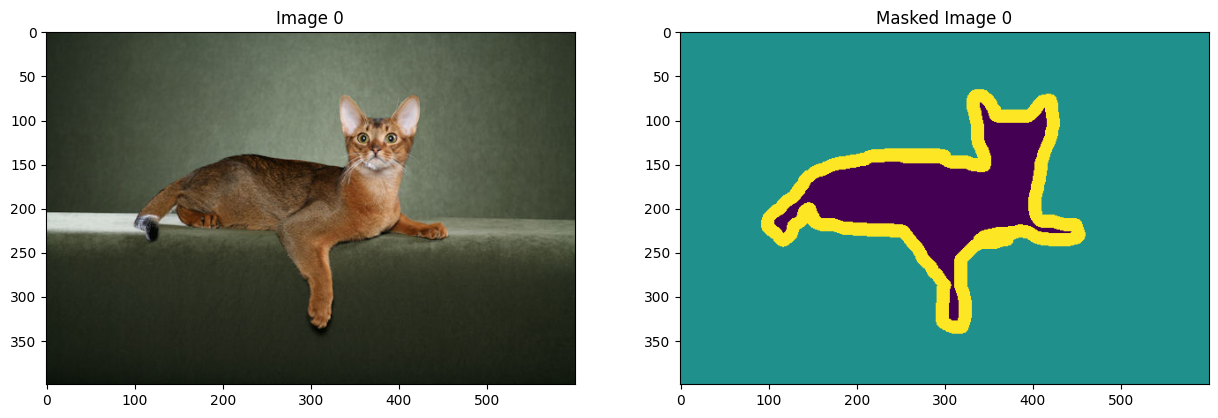

In [5]:
""" Load Train Set and view some examples """
images_dir = 'data/images/'
masks_dir = 'data/masks/'
img, mask = LoadData(images_dir, masks_dir)

# View an example of image and corresponding mask
show_images = 1
for i in range(show_images):
    img_view = imageio.imread(images_dir + img[i])
    mask_view = imageio.imread(masks_dir + mask[i])
    print(img_view.shape)
    print(mask_view.shape)
    fig, arr = plt.subplots(1, 2, figsize=(15, 15))
    arr[0].imshow(img_view)
    arr[0].set_title('Image ' + str(i))
    arr[1].imshow(mask_view)
    arr[1].set_title('Masked Image ' + str(i))

<a name='3'></a>
# 3 - Process Data

X Shape: (7390, 128, 128, 3)
y shape: (7390, 128, 128, 1)
[0 1 2]


Text(0.5, 1.0, 'Processed Masked Image')

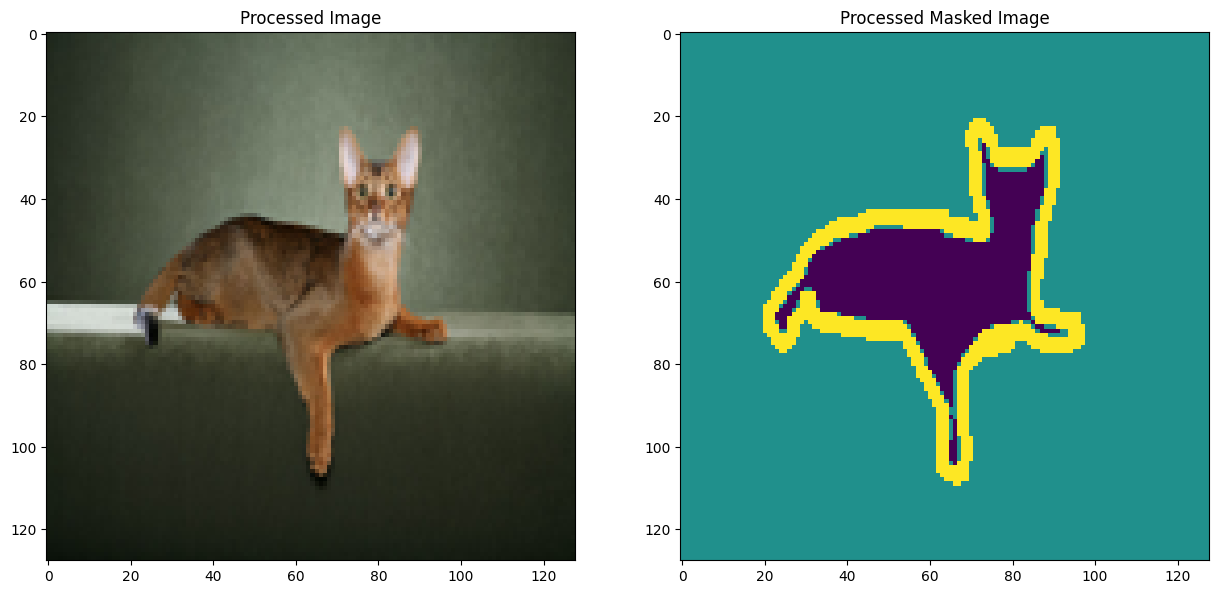

In [6]:
# Define the desired shape
target_shape_img = [128, 128, 3]
target_shape_mask = [128, 128, 1]

# Process data using the helper function
X, y = PreprocessData(img, mask, target_shape_img, target_shape_mask, images_dir, masks_dir)

# QC the shape of output and classes in output dataset
print("X Shape:", X.shape)
print("y shape:", y.shape)
# There are 3 classes: background, pet, outline
print(np.unique(y))

# Visualize the output
image_index = 0
fig, arr = plt.subplots(1, 2, figsize=(15, 15))
arr[0].imshow(X[image_index])
arr[0].set_title('Processed Image')
arr[1].imshow(y[image_index, :, :, 0])
arr[1].set_title('Processed Masked Image')

<a name='4'></a>
# 4 - Split Train and Test Set

In [7]:
# Use scikit-learn's function to split the dataset; 20% held out as the validation set
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Convert to PyTorch tensors. Images: NHWC -> NCHW. Masks: squeeze the channel dim to
# (N, H, W) class-index maps, as expected by nn.CrossEntropyLoss.
X_train_t = torch.from_numpy(X_train).permute(0, 3, 1, 2).float()
X_valid_t = torch.from_numpy(X_valid).permute(0, 3, 1, 2).float()
y_train_t = torch.from_numpy(y_train[..., 0]).long()
y_valid_t = torch.from_numpy(y_valid[..., 0]).long()

train_dataset = TensorDataset(X_train_t, y_train_t)
valid_dataset = TensorDataset(X_valid_t, y_valid_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print('Train:', X_train_t.shape, y_train_t.shape)
print('Valid:', X_valid_t.shape, y_valid_t.shape)

Train: torch.Size([5912, 3, 128, 128]) torch.Size([5912, 128, 128])
Valid: torch.Size([1478, 3, 128, 128]) torch.Size([1478, 128, 128])


<a name='5'></a>
# 5 - Build U-Net Architecture

In [8]:
# Build the model (see unet_model.py for the EncoderMiniBlock/DecoderMiniBlock/UNet definitions)
model = UNet(in_channels=3, n_filters=32, n_classes=3)
model = model.to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parameters: {num_params:,}')

UNet(
  (cblock1): EncoderMiniBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cblock2): EncoderMiniBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cblock3): EncoderMiniBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runn

<a name='6'></a>
# 6 - Train the Model

In [9]:
# There are multiple optimizers and loss functions that can be used to train multi-class
# segmentation models. Ideally, try different options to get the best accuracy.
optimizer = torch.optim.Adam(model.parameters())

train_loss_list, train_acc_list, valid_loss_list, valid_acc_list = train_model(
    model, train_loader, valid_loader, optimizer, DEVICE, num_epochs=20)

Epoch 001/020 | loss: 0.6290 - accuracy: 74.7443 | val_loss: 0.6363 - val_accuracy: 74.4901
Epoch 002/020 | loss: 0.4090 - accuracy: 84.4234 | val_loss: 0.4282 - val_accuracy: 83.7244
Epoch 003/020 | loss: 0.3733 - accuracy: 85.7335 | val_loss: 0.3952 - val_accuracy: 84.7995
Epoch 004/020 | loss: 0.3386 - accuracy: 87.0313 | val_loss: 0.3702 - val_accuracy: 85.8166
Epoch 005/020 | loss: 0.3382 - accuracy: 87.4842 | val_loss: 0.3753 - val_accuracy: 86.1977
Epoch 006/020 | loss: 0.2932 - accuracy: 88.9010 | val_loss: 0.3406 - val_accuracy: 87.2680
Epoch 007/020 | loss: 0.2736 - accuracy: 89.5950 | val_loss: 0.3189 - val_accuracy: 87.9482
Epoch 008/020 | loss: 0.2569 - accuracy: 90.2998 | val_loss: 0.3174 - val_accuracy: 88.1044
Epoch 009/020 | loss: 0.2634 - accuracy: 89.9849 | val_loss: 0.3275 - val_accuracy: 87.8566
Epoch 010/020 | loss: 0.2373 - accuracy: 91.0071 | val_loss: 0.2990 - val_accuracy: 88.7411
Epoch 011/020 | loss: 0.2258 - accuracy: 91.4013 | val_loss: 0.3125 - val_accura

<a name='7'></a>
# 7 - Evaluate Model Results

<a name='7.1'></a>
## 7.1 - Bias Variance Check

High Bias is a characteristic of an underfitted model and we would observe low accuracies for
both train and validation sets. High Variance is a characteristic of an overfitted model and we
would observe high accuracy for the train set and low for the validation set. To check for bias
and variance, plot both curves. The loss curve helps confirm the loss is decreasing with each
iteration, i.e. the model is optimizing fine.

(<Figure size 2000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Comparison'}>,
        <Axes: title={'center': 'Accuracy Comparison'}>], dtype=object))

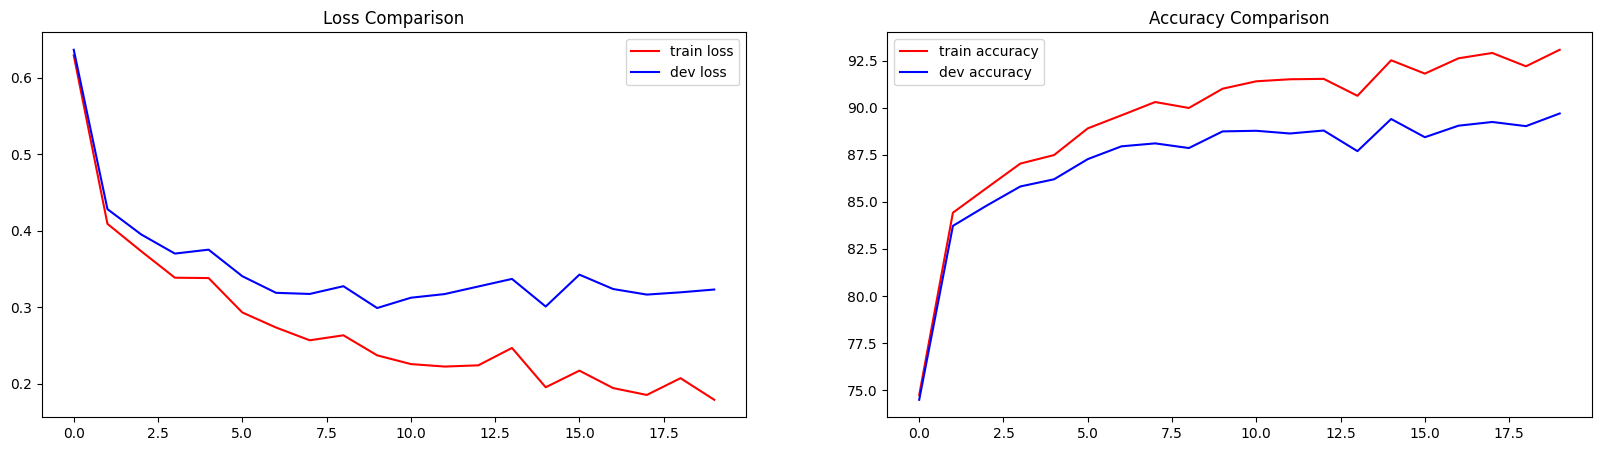

In [10]:
plot_loss_and_accuracy(train_loss_list, valid_loss_list, train_acc_list, valid_acc_list)

# RESULTS
# The train loss should be consistently decreasing, showing that Adam is able to optimize the
# model and find a minimum. Train/validation accuracy that are both high and close together
# indicates low bias and low variance.

<a name='7.2'></a>
## 7.2 - View Predicted Segmentations

In [11]:
valid_loss, valid_acc = compute_epoch_metrics(model, valid_loader, DEVICE)
print(f'Validation loss: {valid_loss:.4f} | Validation accuracy: {valid_acc:.2f}%')

Validation loss: 0.3232 | Validation accuracy: 89.69%


(<Figure size 1500x1500 with 3 Axes>,
 array([<Axes: title={'center': 'Processed Image'}>,
        <Axes: title={'center': 'Actual Masked Image'}>,
        <Axes: title={'center': 'Predicted Masked Image'}>], dtype=object))

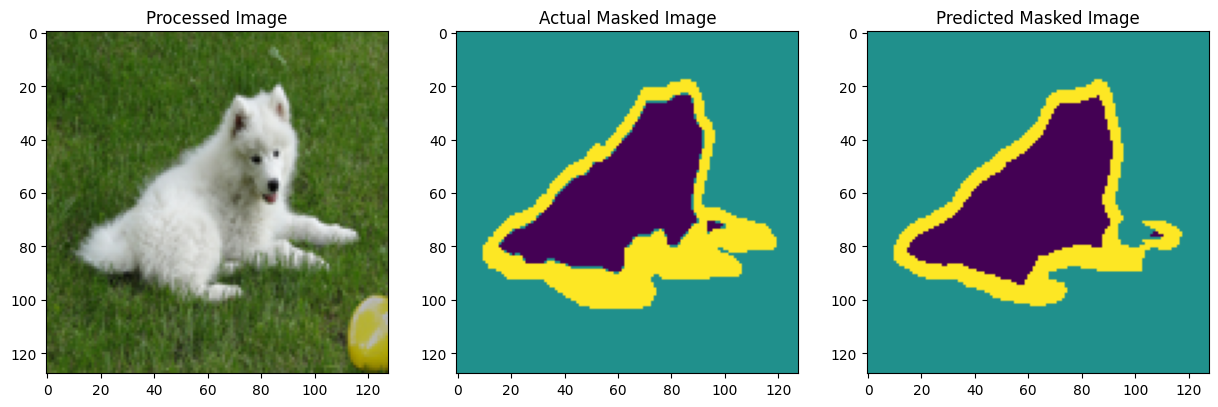

In [12]:
# Add any index (within the validation set size) to contrast the predicted mask with the actual mask
index = 0
visualize_results(model, X_valid_t, X_valid, y_valid, DEVICE, index)